Dataset path: C:\Users\ABI KRISHNAN\.cache\kagglehub\datasets\beatoa\spamassassin-public-corpus\versions\2
Total emails : 4198
Spam         : 1397
Ham          : 2801
Cleaning text …
Done.
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best C = 1  |  CV F1 = 0.9838

=== Classification Report ===
              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99       560
        Spam       0.97      0.99      0.98       280

    accuracy                           0.99       840
   macro avg       0.98      0.99      0.98       840
weighted avg       0.99      0.99      0.99       840

ROC-AUC: 0.9987


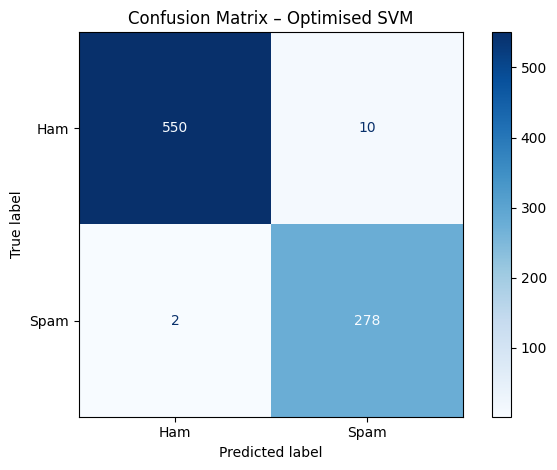


Model + vectorizer saved to models/

=== Sample Predictions ===
  [SPAM  (spam prob: 65.3%)]  Meeting scheduled at 10 am tomorrow – please confirm.
  [SPAM  (spam prob: 97.7%)]  Congratulations! You have WON a FREE lottery. Click here NOW!!!
  [SPAM  (spam prob: 63.8%)]  Please find attached the Q3 project report for your review.
  [SPAM  (spam prob: 80.3%)]  URGENT: Your bank account has been compromised. Verify immediately.


In [16]:
"""
============================================================
  IMPROVED SPAM EMAIL CLASSIFIER - Training Script
============================================================
"""

import kagglehub
import os
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)

# ── 1. Download dataset ──────────────────────────────────
path = kagglehub.dataset_download("beatoa/spamassassin-public-corpus")
print("Dataset path:", path)

# ── 2. Load raw emails ───────────────────────────────────
emails, labels = [], []

def read_emails(folder_path, label):
    for root, _, files in os.walk(folder_path):
        if "__MACOSX" in root:
            continue
        for fname in files:
            if fname.startswith('.'):
                continue
            fpath = os.path.join(root, fname)
            if os.path.isfile(fpath):
                try:
                    with open(fpath, "r", encoding="latin-1") as f:
                        emails.append(f.read())
                        labels.append(label)
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")

read_emails(os.path.join(path, "spam_2"),   1)
read_emails(os.path.join(path, "easy_ham"), 0)
read_emails(os.path.join(path, "hard_ham"), 0)

print(f"Total emails : {len(emails)}")
print(f"Spam         : {labels.count(1)}")
print(f"Ham          : {labels.count(0)}")

# ── 3. Text preprocessing ────────────────────────────────
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def extract_body(raw):
    parts = re.split(r'\n\n', raw, maxsplit=1)
    return parts[1] if len(parts) > 1 else raw

def clean_text(text):
    text = extract_body(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' url ',   text)
    text = re.sub(r'\S+@\S+',           ' email ', text)
    text = re.sub(r'\d+',               ' num ',   text)
    text = re.sub(r'[^\w\s]',           ' ',       text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 1]
    return " ".join(words)

df = pd.DataFrame({"email": emails, "label": labels})
print("Cleaning text …")
df['clean_text'] = df['email'].apply(clean_text)
print("Done.")

# ── 4. Train / test split ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

# ── 5. TF-IDF vectorization ──────────────────────────────
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# ── 6. Optimised SVM ─────────────────────────────────────
param_grid = {'C': [0.01, 0.1, 1, 10]}
base_svm = LinearSVC(class_weight='balanced', max_iter=2000)
grid = GridSearchCV(base_svm, param_grid, cv=5,
                    scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_tfidf, y_train)
print(f"\nBest C = {grid.best_params_['C']}  |  CV F1 = {grid.best_score_:.4f}")

best_svm = CalibratedClassifierCV(
    LinearSVC(C=grid.best_params_['C'],
              class_weight='balanced', max_iter=2000),
    cv=3
)
best_svm.fit(X_train_tfidf, y_train)

# ── 7. Evaluate ──────────────────────────────────────────
y_pred      = best_svm.predict(X_test_tfidf)
y_prob_spam = best_svm.predict_proba(X_test_tfidf)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_spam):.4f}")

fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Ham", "Spam"]).plot(ax=ax, cmap='Blues')
ax.set_title("Confusion Matrix – Optimised SVM")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

# ── 8. Save model ────────────────────────────────────────
os.makedirs("models", exist_ok=True)
joblib.dump(best_svm, "models/spam_model.pkl")
joblib.dump(tfidf,    "models/vectorizer.pkl")
print("\nModel + vectorizer saved to models/")

# ── 9. Smoke test ────────────────────────────────────────
def predict(text):
    vec  = tfidf.transform([clean_text(text)])
    prob = best_svm.predict_proba(vec)[0]
    label = "SPAM" if prob[1] > 0.5 else "HAM"
    return f"{label}  (spam prob: {prob[1]:.1%})"

samples = [
    "Meeting scheduled at 10 am tomorrow – please confirm.",
    "Congratulations! You have WON a FREE lottery. Click here NOW!!!",
    "Please find attached the Q3 project report for your review.",
    "URGENT: Your bank account has been compromised. Verify immediately.",
]

print("\n=== Sample Predictions ===")
for s in samples:
    print(f"  [{predict(s)}]  {s[:70]}")